/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


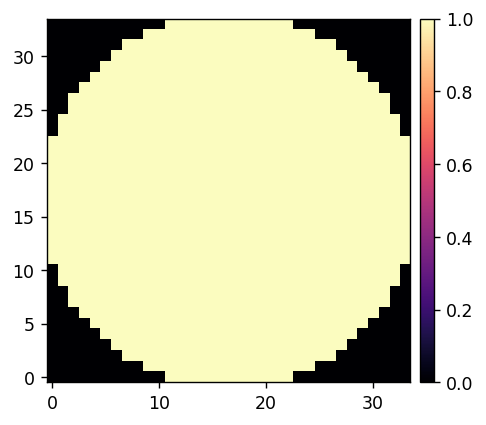

ERROR:purepyindi2.transports:Connection failed. Reconnecting to localhost:7624 in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monitor
    self._socket.connect((self.host, self.port))
ConnectionRefusedError: [Errno 111] Connection refused
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monitor
    self._socket.connect((self.host, self.port))
ConnectionRefusedError: [Errno 111] Connection refused
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monit

In [1]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import llowfsc
from scoob_llowfsc import wfe

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()
    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

data_path = scoob_llowfsc.path/'exp-data'

In [2]:
dm_wfe_name = 'dm00disp01'

dm_wfe_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_wfe_name}/')

dm_wfe_stream = ImageStream(dm_wfe_name)

# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
wfe_data_path = data_path/f'exp-{today}'/'wfe'
wfe_telem_path = wfe_data_path/'raw-telem'
wfe_unpacked_path = wfe_data_path/'unpacked-telem'

In [3]:
telem.make_dir(exp_path)
telem.make_dir(wfe_data_path)
telem.make_dir(wfe_telem_path)
telem.make_dir(wfe_unpacked_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem' already exists.


In [4]:
from astropy.io import fits
wfe_cube = fits.getdata('/opt/MagAOX/calib/dm/kilo/wfe_cube_30min_500Hz_looped_64bit.fits')
print(wfe_cube.shape)

(1799998, 34, 34)


In [5]:
interval = 1/500
print(interval)

0.002


# Delete telemetry data if needed to keep data organized.

In [6]:
reload(telem)
telem.delete_files(dm_wfe_rawims_path/'*.xrif')
telem.delete_files(wfe_telem_path/'*')
telem.delete_files(wfe_unpacked_path/f'*')

# Inject WFE with a while loop running at a specific frequency.

In [8]:
reload(telem)
telem.toggle(1, dm_wfe_name, client0, delay=0.5)

In [9]:
reload(llowfsc)

# telem.toggle(1, dm_wfe_name, client0, delay=0.5)

llowfsc.inject_wfe_cube(
    wfe_cube,
    dm_wfe_stream,
    interval,
    # interval_offset=250e-6,
)

# telem.toggle(0, dm_wfe_name, client0)


Injecting WFE ...
Stopped injecting WFE.


In [10]:
reload(telem)
telem.toggle(0, dm_wfe_name, client0)

# Analyze telemetry data.

In [11]:
telem.move_files(dm_wfe_rawims_path, wfe_telem_path)

In [12]:
telem.unpack_data(wfe_telem_path, wfe_unpacked_path)

In [ ]:
dm_wfe_fnames = telem.get_fnames(wfe_unpacked_path/f'{dm_wfe_name}*')
dm_wfe_fnames[:5], dm_wfe_fnames[-5:]

(['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250414193359854218634.fits'],
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250414193359854218634.fits'])

In [15]:
reload(telem)
absolute = 1
dm_wfe_times = telem.read_telem_times(dm_wfe_fnames, absolute=absolute)
dm_wfe_start = dm_wfe_times[0]

/opt/conda/envs/km310env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/envs/km310env/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'dm00disp01 Delta Times: FPS = nan')

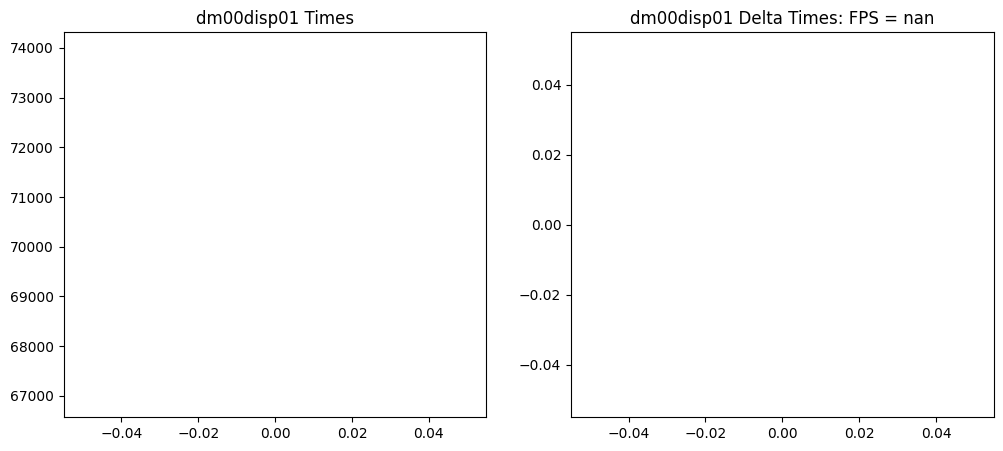

In [16]:
dm_wfe_delTs = dm_wfe_times[1:] - dm_wfe_times[:-1]
mean_fps = 1/np.mean(dm_wfe_delTs)

fig = plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(dm_wfe_times)
plt.title(f'{dm_wfe_name} Times')

plt.subplot(122)
plt.plot(dm_wfe_delTs)
plt.title(f'{dm_wfe_name} Delta Times: FPS = {mean_fps}')

In [ ]:
absolute = 1
dm_wfe_data, dm_wfe_times = telem.read_telem_data(dm_wfe_fnames, absolute=absolute)
dm_wfe_start = dm_wfe_times[0]

Text(0.5, 1.0, 'dm00disp01 Delta Times: FPS = 1048.8374575447203')

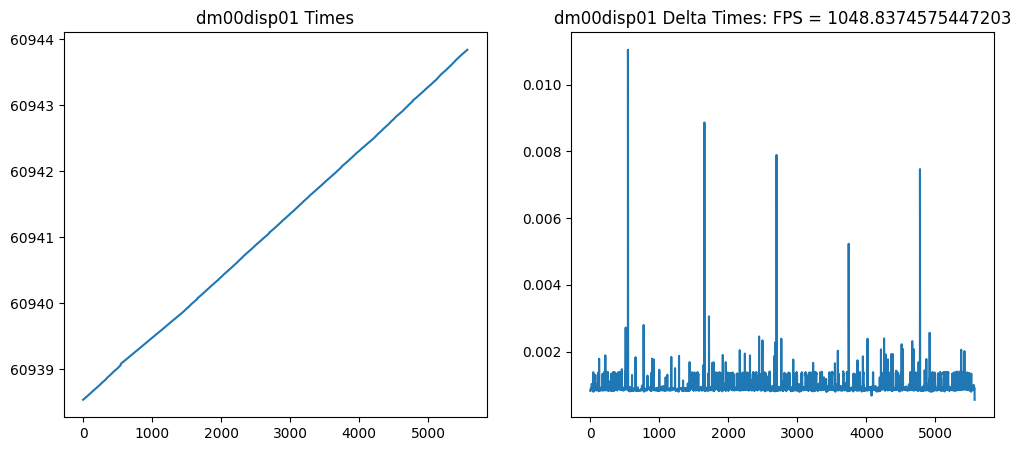

In [42]:
dm_wfe_delTs = dm_wfe_times[1:] - dm_wfe_times[:-1]
mean_fps = 1/np.mean(dm_wfe_delTs)

fig = plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(dm_wfe_times)
plt.title(f'{dm_wfe_name} Times')

plt.subplot(122)
plt.plot(dm_wfe_delTs)
plt.title(f'{dm_wfe_name} Delta Times: FPS = {mean_fps}')